# Camera Calibration Using Moon Observations

This notebook implements camera calibration using video observations of the moon from a fixed camera position.
The approach follows these key steps:
1. Video preprocessing to extract clear moon frames
2. Moon detection using circular Hough transform
3. Sub-pixel accuracy with ellipse fitting
4. Astronomical calculations for expected moon positions
5. Least squares optimization for parameter refinement

In [2]:
# Enable interactive matplotlib backend
# %matplotlib widget

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation, AltAz, get_body, ITRS
from astropy import units as u
import pandas as pd
from datetime import datetime
import os
from typing import Tuple, Optional
import pymap3d as pm

#

In [4]:
from pyproj import Transformer, CRS
import numpy as np
import cv2
import pymap3d as pm


def ecef_to_enu(origin_ecef, points_ecef):

    # use pymap3d to convert ecef to enu
    enu_points = pm.ecef2enu(points_ecef[:, 0], points_ecef[:, 1], points_ecef[:, 2],
                              origin_ecef[0], origin_ecef[1], origin_ecef[2])
    # make numpy array
    return np.array(enu_points).T


def gps_to_camxy_vasha_fixed(lats, lons, alts, cam_ecef, cam_k, cam_r, cam_t, camera_gps, distortion=None):
    """
    Fixed version of GPS to camera coordinates conversion.
    Properly handles objects behind camera and outside frame.
    """
    # Convert GPS to ECEF
    transformer_geodetic_to_ecef = Transformer.from_crs(
        "epsg:4979", "epsg:4978", always_xy=True)
    eX, eY, eZ = transformer_geodetic_to_ecef.transform(lons, lats, alts)
    ecef_points = np.column_stack((eX, eY, eZ))

    # Convert ECEF to ENU relative to camera
    enu_points = ecef_to_enu(
        camera_gps, ecef_points)  # Shape: (N, 3)

    # CRITICAL FIX 1: Transform to camera coordinate system properly
    # Camera coordinates: X=right, Y=down, Z=forward (into scene)
    points_cam = (cam_r @ enu_points.T + cam_t).T  # Shape: (N, 3)

    # CRITICAL FIX 2: Filter out points behind camera BEFORE projection
    # Points with negative Z are behind the camera
    behind_camera_mask = points_cam[:, 2] <= 0

    # Initialize output arrays
    num_points = len(lats)
    image_x = np.full(num_points, np.nan)
    image_y = np.full(num_points, np.nan)
    cam_distance = points_cam[:, 2]  # Z coordinate is the distance

    # Only project points in front of camera
    if np.any(~behind_camera_mask):
        valid_points = enu_points[~behind_camera_mask]

        # Project using OpenCV
        rvec, _ = cv2.Rodrigues(cam_r)
        tvec = cam_t.astype(np.float32)

        if distortion is None:
            distortion = np.zeros((5, 1), dtype=np.float32)

        image_points, _ = cv2.projectPoints(
            valid_points.astype(np.float32),
            rvec, tvec, cam_k, distortion
        )
        image_points = image_points.reshape(-1, 2)

        # Assign projected coordinates back to output arrays
        valid_indices = np.where(~behind_camera_mask)[0]
        image_x[valid_indices] = image_points[:, 0]
        image_y[valid_indices] = image_points[:, 1]

    return image_x, image_y, cam_distance

def gps_to_ecef(points_gps):
    transformer_geodetic_to_ecef = Transformer.from_crs(
        "epsg:4979", "epsg:4978", always_xy=True)
    eX, eY, eZ = transformer_geodetic_to_ecef.transform(
        points_gps[:, 1], points_gps[:, 0], points_gps[:, 2])
    ecef_points = np.vstack((eX, eY, eZ)).T  # Shape: (N, 3)
    return ecef_points

def estimate_camera_params(origin_gps, poi_ecef, poi_xy, frame_size, intrinsics_estimate=None, distortion_estimate=None, rvecs=None, tvecs=None):
    # Convert camera GPS coordinates to ECEF
    transformer_geodetic_to_ecef = Transformer.from_crs(
        "epsg:4979", "epsg:4978", always_xy=True)
    # Note: pyproj expects lon,lat,alt order
    eX, eY, eZ = transformer_geodetic_to_ecef.transform(
        origin_gps[1], origin_gps[0], origin_gps[2])
    cam_ecef = np.array([eX, eY, eZ]).T  # /1000  # Shape: (3,)
    # eX, eY, eZ = transformer_geodetic_to_ecef.transform(
    #     poi_gps[:, 1], poi_gps[:, 0], poi_gps[:, 2])
    # poi_ecef = np.vstack((eX, eY, eZ)).T  # /1000  # Shape: (3, N)
    poi_enu = ecef_to_enu(
        origin_gps, poi_ecef)  # Shape: (N,3)

    # Put everything in contiguous arrays with (N, 3), not (3, N)
    object_points = np.ascontiguousarray(poi_enu.astype(np.float32))  # (N, 3)
    image_points = np.ascontiguousarray(
        poi_xy.astype(np.float32))      # (N, 2)

    if intrinsics_estimate is None:
        estimated_focal_dist = 1e5
        intrinsics_estimate = np.array([[estimated_focal_dist, 0, frame_size[1] / 2],
                                        [0, estimated_focal_dist,
                                            frame_size[0] / 2],
                                        [0, 0, 1]], dtype=np.float32)  # (3, 3)
    if distortion_estimate is None:
        # Use a zero distortion model if not provided
        distortion_estimate = np.zeros((5, 1), dtype=np.float32)

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        10000,    # Maximum 10,000 iterations (vs default ~30)
        1e-12     # Extremely tight convergence (vs default 1e-6)
    )
    print("Initial intrinsics:\n", intrinsics_estimate)
    print("Initial distortion:\n", distortion_estimate.ravel())
    calibrate_flags = (
        cv2.CALIB_USE_INTRINSIC_GUESS |         # Use your good initial guess
        # cv2.CALIB_USE_LU |                    # Use your good initial guess
        cv2.CALIB_FIX_PRINCIPAL_POINT  |        # Keep principal point fixed
        # cv2.CALIB_FIX_FOCAL_LENGTH |          # Keep focal lengths fixed
        cv2.CALIB_FIX_ASPECT_RATIO |            # Keep fx/fy ratio fixed
        # cv2.CALIB_FIX_K1 |
        # cv2.CALIB_FIX_K2 | 
        # cv2.CALIB_FIX_K3 |      # keep all c
        # cv2.CALIB_FIX_P1 | 
        # CALIB_FIX_P2 |  #fix tangential distortion
        # fix higher order radial distortions
        cv2.CALIB_FIX_K4 | cv2.CALIB_FIX_K5 | cv2.CALIB_FIX_K6 |
        cv2.CALIB_ZERO_TANGENT_DIST           # Only estimate radial distortion
        | cv2.CALIB_USE_EXTRINSIC_GUESS
    )
    # Let OpenCV estimate all distortion parameters
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        [object_points], [image_points], frame_size,
        intrinsics_estimate,
        distortion_estimate,
        rvecs,
        tvecs,
        flags=calibrate_flags,
        criteria=criteria
    )

    T = tvecs[0]  # .reshape(3, 1)  # Reshape to (3, 1)
    R, _ = cv2.Rodrigues(rvecs[0])

    return camera_matrix, dist_coeffs, R, T, cam_ecef


def calculate_fov_from_intrinsics(intrinsics, image_width, image_height, distortion=None):
    """
    Calculate horizontal and vertical field of view from camera intrinsics matrix.

    *** NOTE: This method assumes no distortion is applied.
    Without distortion -  ***

    Args:
        intrinsics: 3x3 camera intrinsics matrix (K matrix)
        image_width: Width of the image in pixels
        image_height: Height of the image in pixels
        distortion: Optional distortion coefficients (not used in this calculation)

    Returns:
        hfov: Horizontal field of view in radians
        vfov: Vertical field of view in radians
        hfov_deg: Horizontal field of view in degrees
        vfov_deg: Vertical field of view in degrees
    """
    # Extract focal lengths and principal point
    fx = intrinsics[0, 0]  # focal length in x (pixels)
    fy = intrinsics[1, 1]  # focal length in y (pixels)
    cx = intrinsics[0, 2]  # principal point x
    cy = intrinsics[1, 2]  # principal point y

    # Left and right angles from principal point
    angle_left = np.arctan(cx / fx)
    angle_right = np.arctan((image_width - cx) / fx)
    hfov = angle_left + angle_right

    # Top and bottom angles from principal point
    angle_top = np.arctan(cy / fy)
    angle_bottom = np.arctan((image_height - cy) / fy)
    vfov = angle_top + angle_bottom

    # Method 2: Simplified calculation (assumes centered principal point)
    # hfov_simple = 2 * np.arctan(image_width / (2 * fx))
    # vfov_simple = 2 * np.arctan(image_height / (2 * fy))

    # Convert to degrees for display
    hfov_deg = np.degrees(hfov)
    vfov_deg = np.degrees(vfov)

    # return hfov, vfov, hfov_deg, vfov_deg
    return (hfov_deg.item(), vfov_deg.item())

In [7]:
from PIL import Image

focal_length_deg = 63.59  # Example: 60 degrees
default_img = Image.open(os.path.join("/Users/shrenikborad/Downloads/NNDL/calib_data/u_a/", "DEFAULT.jpg"))
frame_size = (default_img.height, default_img.width)
focal_length = 0.5 * frame_size[0] / \
            np.tan(0.5 * np.radians(focal_length_deg))

# Create initial K matrix (intrinsics)
initial_k = np.array([
    [focal_length, 0, frame_size[1] / 2],
    [0, focal_length, frame_size[0] / 2],
    [0, 0, 1]
], dtype=np.float32)

In [13]:
poi_csv = "/Users/shrenikborad/Downloads/NNDL/calib_data/u_a/UA_POIsMore.csv"
poi_data = pd.read_csv(poi_csv)
poi_data.head()
origin_gps = (poi_data.iloc[0]['lat'], poi_data.iloc[0]['lon'], poi_data.iloc[0]['alt'])

poi_data_final = poi_data[1:]
poi_data_final["img_x"] = poi_data_final["x_cam"]
poi_data_final["img_y"] = poi_data_final["y_cam"]
poi_data_final["map_lat"] = poi_data_final["lat"]
poi_data_final["map_lng"] = poi_data_final["lon"]
poi_data_final["map_altitude"] = poi_data_final["alt"]

/var/folders/nk/x5y68p8n5v529rrl_01kmfh80000gn/T/ipykernel_54999/692001655.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_data_final["img_x"] = poi_data_final["x_cam"]
/var/folders/nk/x5y68p8n5v529rrl_01kmfh80000gn/T/ipykernel_54999/692001655.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_data_final["img_y"] = poi_data_final["y_cam"]
/var/folders/nk/x5y68p8n5v529rrl_01kmfh80000gn/T/ipykernel_54999/692001655.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [14]:
poi_xy = poi_data_final[['img_x', 'img_y']].to_numpy()
poi_xy
poi_gps = poi_data_final[['map_lat', 'map_lng', 'map_altitude']].to_numpy()
poi_gps
poi_ecef = gps_to_ecef(poi_gps)
poi_ecef

array([[-1931591.54762284, -5043891.96087813,  3382486.62606082],
       [-1931561.6376845 , -5043926.54862314,  3382452.26581774],
       [-1931572.0459718 , -5043885.45728241,  3382514.73093872],
       [-1931534.81945048, -5043899.08428932,  3382515.44181208],
       [-1931559.37752877, -5043854.43663154,  3382567.72144085],
       [-1931553.93576649, -5043906.13980053,  3382486.94444689],
       [-1931002.72015374, -5043984.70559345,  3382709.52794856],
       [-1931360.6495719 , -5043876.27678043,  3382669.08827556],
       [-1931242.93701835, -5043925.22578466,  3382692.14701841],
       [-1931040.19755451, -5043947.24969835,  3382738.46069883],
       [-1927497.40841664, -5037257.10191453,  3396229.12645078],
       [-1926809.7076839 , -5037274.97775593,  3396082.85548574],
       [-1926084.5456382 , -5037478.78382486,  3396760.69685184],
       [-1924298.94352743, -5039273.71264797,  3395438.48041471],
       [-1919048.51877361, -5040373.69199073,  3397766.5288695 ],
       [-1

In [35]:
# merge moon_ecefs and poi_ecef
all_poi_ecef = np.vstack(( poi_ecef[:9]))
all_poi_xy = np.vstack(( poi_xy[:9]))
print(all_poi_ecef)
print(all_poi_xy)

[[-1931591.54762284 -5043891.96087813  3382486.62606082]
 [-1931561.6376845  -5043926.54862314  3382452.26581774]
 [-1931572.0459718  -5043885.45728241  3382514.73093872]
 [-1931534.81945048 -5043899.08428932  3382515.44181208]
 [-1931559.37752877 -5043854.43663154  3382567.72144085]
 [-1931553.93576649 -5043906.13980053  3382486.94444689]
 [-1931002.72015374 -5043984.70559345  3382709.52794856]
 [-1931360.6495719  -5043876.27678043  3382669.08827556]
 [-1931242.93701835 -5043925.22578466  3382692.14701841]]
[[1324.77 1243.31]
 [2547.03 1205.22]
 [1334.95 1040.65]
 [1833.76 1000.93]
 [1014.88  954.19]
 [1989.57 1127.31]
 [2538.38  779.33]
 [1832.57  798.33]
 [2173.08  725.66]]


In [36]:
k_matrix, dist_coeffs, r_matrix, t_vector, cam_ecef_coords = estimate_camera_params(origin_gps=origin_gps,
                       poi_ecef=all_poi_ecef,
                       poi_xy=all_poi_xy,
                       frame_size=frame_size,
                       intrinsics_estimate=initial_k,
                       distortion_estimate=None)

print("Estimated K matrix:\n", k_matrix)
print("Estimated distortion coefficients:\n", dist_coeffs.ravel())
print("Estimated rotation matrix:\n", r_matrix)
print("Estimated translation vector:\n", t_vector)

Initial intrinsics:
 [[1.1614674e+03 0.0000000e+00 1.2800000e+03]
 [0.0000000e+00 1.1614674e+03 7.2000000e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]
Initial distortion:
 [0. 0. 0. 0. 0.]
Estimated K matrix:
 [[2.01819989e+03 0.00000000e+00 1.28000000e+03]
 [0.00000000e+00 2.01819989e+03 7.20000000e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Estimated distortion coefficients:
 [-0.61462169  0.95351423  0.          0.         -0.68877484]
Estimated rotation matrix:
 [[ 9.03538670e-01 -4.28505453e-01 -9.73464458e-04]
 [ 1.09838865e-02  2.54313147e-02 -9.99616228e-01]
 [ 4.28365761e-01  9.03181225e-01  2.76848316e-02]]
Estimated translation vector:
 [[ 31.61642728]
 [-11.76524884]
 [ 17.1258179 ]]


In [37]:
import json
camera_params = {
    "intrinsics": k_matrix.tolist(),
    "distortion": dist_coeffs.ravel().tolist(),
    "rotation": r_matrix.tolist(),
    "translation": t_vector.ravel().tolist(),
    "origin_gps": {
        "lat": origin_gps[0],
        "lon": origin_gps[1],
        "alt": origin_gps[2]
    }}
with open("/Users/shrenikborad/Downloads/NNDL/calib_data/u_a/camera_params.json", "w") as f:
    json.dump(camera_params, f, indent=4)

In [38]:
r_matrix.shape, t_vector.shape, dist_coeffs.shape

((3, 3), (3, 1), (5, 1))

In [28]:
type(poi_gps[:, 0][0])

numpy.float64

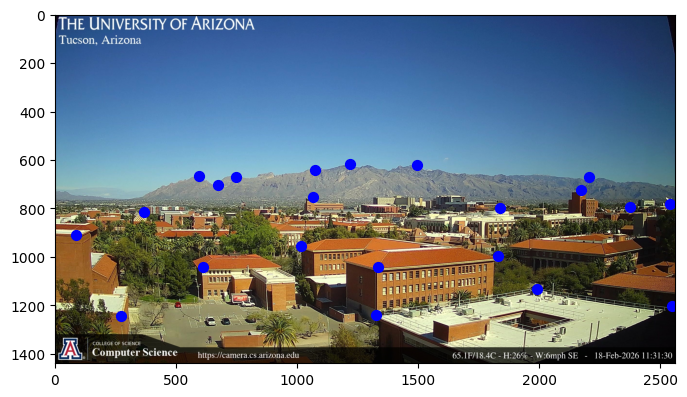

In [39]:
image_x, image_y, cam_distance = gps_to_camxy_vasha_fixed(
            poi_gps[:, 0],  # lats
            poi_gps[:, 1],  # lons
            poi_gps[:, 2],  # alts
            cam_k=k_matrix,
            cam_r=r_matrix,
            cam_t=t_vector,
            cam_ecef=cam_ecef_coords,
            camera_gps=origin_gps,
            distortion=dist_coeffs
        )

# plot the reprojected points on the default image
plt.figure(figsize=(8, 6))
plt.imshow(default_img)
plt.scatter(image_x, image_y, c='blue', s=50, marker='o', label='Reprojected POIs')

Initial intrinsics:
 [[1.1614674e+03 0.0000000e+00 1.2800000e+03]
 [0.0000000e+00 1.1614674e+03 7.2000000e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]
Initial distortion:
 [0. 0. 0. 0. 0.]


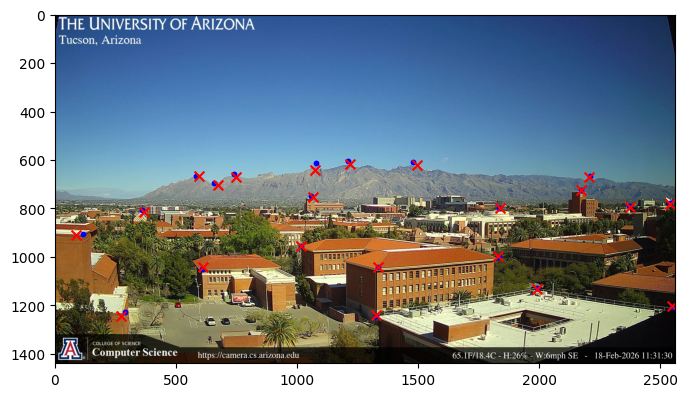

In [40]:
def plotpoints():
    k_matrix, dist_coeffs, r_matrix, t_vector, cam_ecef_coords = estimate_camera_params(origin_gps=origin_gps,
                       poi_ecef=all_poi_ecef,
                       poi_xy=all_poi_xy,
                       frame_size=frame_size,
                       intrinsics_estimate=initial_k,
                       distortion_estimate=None)

    image_x, image_y, cam_distance = gps_to_camxy_vasha_fixed(
                poi_gps[:, 0],  # lats
                poi_gps[:, 1],  # lons
                poi_gps[:, 2],  # alts
                cam_k=k_matrix,
                cam_r=r_matrix,
                cam_t=t_vector,
                cam_ecef=cam_ecef_coords,
                camera_gps=origin_gps,
                distortion=dist_coeffs
            )

    # plot the reprojected points on the default image
    plt.figure(figsize=(8, 6))
    plt.imshow(default_img)
    for i, (x, y) in enumerate(poi_xy):
        # draw as cross
        plt.scatter(x, y, c='blue', s=10, marker='o')
    plt.scatter(image_x, image_y, c='red', s=50, marker='x', label='Reprojected POIs')
    # draw moon on each image
plotpoints()

In [37]:
def image_to_gps(image_x, image_y, k_matrix, r_matrix, t_vector, dist_coeffs, camera_gps, distance_m=1000):
    """
    Convert image pixel coordinates to GPS coordinates at a fixed distance from camera.
    
    Args:
        image_x, image_y: Pixel coordinates in the image
        k_matrix: Camera intrinsics matrix (3x3)
        r_matrix: Camera rotation matrix (3x3) 
        t_vector: Camera translation vector (3x1)
        dist_coeffs: Distortion coefficients
        camera_gps: Camera GPS location [lat, lon, alt]
        distance_m: Distance from camera in meters (default: 1000m)
    
    Returns:
        [lat, lon, alt]: GPS coordinates of the point
    """
    # Convert image point to normalized camera coordinates
    image_point = np.array([[image_x, image_y]], dtype=np.float32)
    
    # Undistort the image point
    undistorted_points = cv2.undistortPoints(image_point, k_matrix, dist_coeffs)
    
    # Get normalized coordinates (in camera frame)
    x_norm = undistorted_points[0, 0, 0]
    y_norm = undistorted_points[0, 0, 1]
    
    # Create ray direction in camera coordinates
    # Camera coordinates: X=right, Y=down, Z=forward
    ray_camera = np.array([x_norm, y_norm, 1.0])
    
    # Normalize the ray direction to unit length
    ray_camera_unit = ray_camera / np.linalg.norm(ray_camera)
    
    # Transform ray to world (ENU) coordinates
    # R transforms from ENU to camera, so R.T transforms from camera to ENU
    ray_world_unit = r_matrix.T @ ray_camera_unit
    
    # Get camera position in ENU coordinates (origin is at camera_gps)
    camera_enu = -r_matrix.T @ t_vector.flatten()
    
    # Calculate the 3D point at fixed distance along the ray
    point_enu = camera_enu + distance_m * ray_world_unit
    
    # Convert ENU to GPS coordinates
    point_lat, point_lon, point_alt = pm.enu2geodetic(
        point_enu[0], point_enu[1], point_enu[2],
        camera_gps[0], camera_gps[1], camera_gps[2]
    )
    
    return [point_lat, point_lon, point_alt]

In [38]:
def create_camera_frustum_kml(k_matrix, r_matrix, t_vector, dist_coeffs, camera_gps, frame_size, distance_m=1000, kml_filename="camera_frustum.kml"):
    """
    Create a KML file showing the camera frustum with the 4 corners of the image.
    
    Args:
        k_matrix: Camera intrinsics matrix (3x3)
        r_matrix: Camera rotation matrix (3x3) 
        t_vector: Camera translation vector (3x1)
        dist_coeffs: Distortion coefficients
        camera_gps: Camera GPS location [lat, lon, alt]
        frame_size: Image dimensions (height, width)
        distance_m: Distance from camera to project corners (default: 1000m)
        kml_filename: Output KML filename
    
    Returns:
        None (saves KML file)
    """
    import xml.etree.ElementTree as ET
    
    # Get image dimensions
    img_height, img_width = frame_size
    
    # Define the 4 corners of the image in pixel coordinates
    corners_pixels = [
        [0, 0],                    # Top-left
        [img_width, 0],           # Top-right
        [img_width, img_height],  # Bottom-right
        [0, img_height]           # Bottom-left
    ]
    
    # Convert each corner to GPS coordinates
    corner_gps = []
    corner_names = ["Top-Left", "Top-Right", "Bottom-Right", "Bottom-Left"]
    
    for i, (px, py) in enumerate(corners_pixels):
        gps_coord = image_to_gps(px, py, k_matrix, r_matrix, t_vector, 
                                dist_coeffs, camera_gps, distance_m)
        corner_gps.append(gps_coord)
        print(f"{corner_names[i]} corner: {gps_coord}")
    
    # Create KML structure
    kml = ET.Element("kml", xmlns="http://www.opengis.net/kml/2.2")
    document = ET.SubElement(kml, "Document")
    
    # Add document name
    name = ET.SubElement(document, "name")
    name.text = "Camera Frustums"
    
    # Add frustum lines from camera to each corner (4 separate LineString placemarks)
    for i, (gps_coord, corner_name) in enumerate(zip(corner_gps, corner_names)):
        line_placemark = ET.SubElement(document, "Placemark")
        line_name = ET.SubElement(line_placemark, "name")
        line_name.text = f"Camera Frustum Ray {i+1}"
        
        linestring = ET.SubElement(line_placemark, "LineString")
        altitude_mode = ET.SubElement(linestring, "altitudeMode")
        altitude_mode.text = "absolute"
        line_coords = ET.SubElement(linestring, "coordinates")
        line_coords.text = f"{camera_gps[1]},{camera_gps[0]},{round(camera_gps[2])}\n{gps_coord[1]},{gps_coord[0]},{round(gps_coord[2])}"
    
    # Add connecting outline (closed rectangle at distance)
    outline_placemark = ET.SubElement(document, "Placemark")
    outline_linestring = ET.SubElement(outline_placemark, "LineString")
    outline_altitude_mode = ET.SubElement(outline_linestring, "altitudeMode")
    outline_altitude_mode.text = "absolute"
    outline_coords = ET.SubElement(outline_linestring, "coordinates")
    
    # Create closed outline by connecting all corners and returning to first
    coord_string = ""
    for gps_coord in corner_gps:
        coord_string += f"{gps_coord[1]},{gps_coord[0]},{round(gps_coord[2])}\n"
    # Close the outline by adding the first point again
    coord_string += f"{corner_gps[0][1]},{corner_gps[0][0]},{round(corner_gps[0][2])}"
    outline_coords.text = coord_string
    
    # Write KML file
    tree = ET.ElementTree(kml)
    ET.indent(tree, space="  ", level=0)
    tree.write(kml_filename, encoding="utf-8", xml_declaration=True)
    
    print(f"KML file saved as: {kml_filename}")
    print(f"Camera FOV spans from {min([c[0] for c in corner_gps]):.6f} to {max([c[0] for c in corner_gps]):.6f} latitude")
    print(f"Camera FOV spans from {min([c[1] for c in corner_gps]):.6f} to {max([c[1] for c in corner_gps]):.6f} longitude")
    
    return corner_gps

# Usage example:
corner_coordinates = create_camera_frustum_kml(
    k_matrix=k_matrix,
    r_matrix=r_matrix, 
    t_vector=t_vector,
    dist_coeffs=dist_coeffs,
    camera_gps=[origin_lat, origin_lon, origin_alt],
    frame_size=frame_size,
    distance_m=1000,
    kml_filename="camera_frustum_1km.kml"
)

Top-Left corner: [np.float64(43.075989699622276), np.float64(-89.39971935461215), np.float64(888.8406519019057)]
Top-Right corner: [np.float64(43.06499057224613), np.float64(-89.40033574149847), np.float64(907.5573137818507)]
Bottom-Right corner: [np.float64(43.06480325509943), np.float64(-89.39827015591887), np.float64(5.895794154463584)]
Bottom-Left corner: [np.float64(43.07580392923256), np.float64(-89.39765330839904), np.float64(-12.823523783932933)]
KML file saved as: camera_frustum_1km.kml
Camera FOV spans from 43.064803 to 43.075990 latitude
Camera FOV spans from -89.400336 to -89.397653 longitude
